***
Part of the code are based on paper and code: 

S. Zhao, Y. Peng, Y. Zhang, and H. Wang, "Parameter Estimation of Power Electronic
       Converters with Physics-informed Machine Learning", IEEE Trans. Power Electronics, 2022.

 https://github.com/ms140429/PIML_Converter/blob/main/PIML_Converter.py

***

In [49]:
from numba import njit
from SALib.sample import saltelli
from scipy.signal import sawtooth
from SALib.sample import saltelli
from SALib.analyze import sobol

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
import cma, time
from scipy.optimize import least_squares
from scipy.optimize import minimize

import torch, random, numpy as np

import subprocess



def export_to_emf(input_svg, output_emf):
    """
    Uses Inkscape to convert an SVG file to an EMF file.

    Parameters:
        input_svg (str): Path to the input SVG file.
        output_emf (str): Path to save the output EMF file.
    """
    try:
        # Command to run Inkscape for exporting to EMF
        command = [
            "inkscape",  # Ensure Inkscape is in your system PATH
            input_svg,   # Input SVG file
            "--export-type=emf",  # Specify export type as EMF
            "--export-filename=" + output_emf  # Specify output file path
        ]

        # Run the command
        subprocess.run(command, check=True)
        print(f"Successfully exported {input_svg} to {output_emf}.")
    except FileNotFoundError:
        print("Error: Inkscape is not installed or not in your PATH.")
    except subprocess.CalledProcessError as e:
        print(f"Error during conversion: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")



In [2]:
V1 = 48
P1 = 300 * 0.25
P2 = 300
R1 = V1*V1/P1
R2 = V1*V1/P2

[R1, R2]

[30.72, 7.68]

In [3]:

# Replace the file address
file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/Open_source_code/"


      t         i          v  s  vcarrier         d
0  0.05  7.257854  22.825332  0     0.996  0.755269
1  0.05  7.253641  22.824924  0     0.992  0.755269
2  0.05  7.249429  22.824515  0     0.988  0.755269
3  0.05  7.245216  22.824106  0     0.984  0.755269
4  0.05  7.241004  22.823697  0     0.980  0.755269


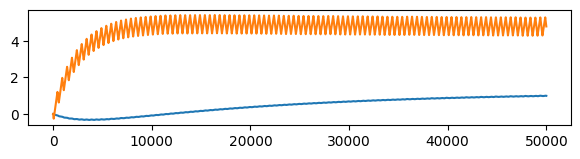

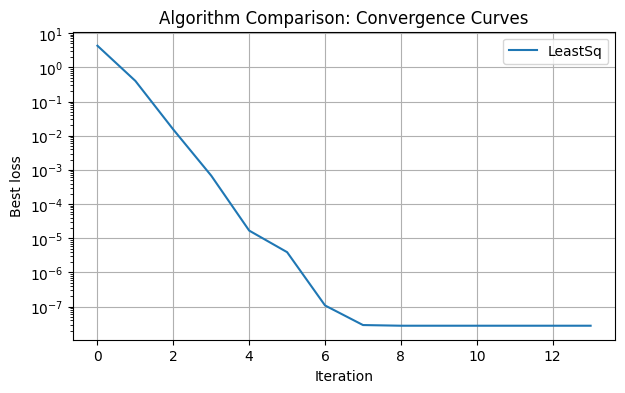


=== Final Comparison ===
LeastSq: final loss=2.7707e-08, time=2.25s, params=[1.00013502 1.03190499 0.96770254 0.99306088 0.9834158  1.00392089
 0.99428763]


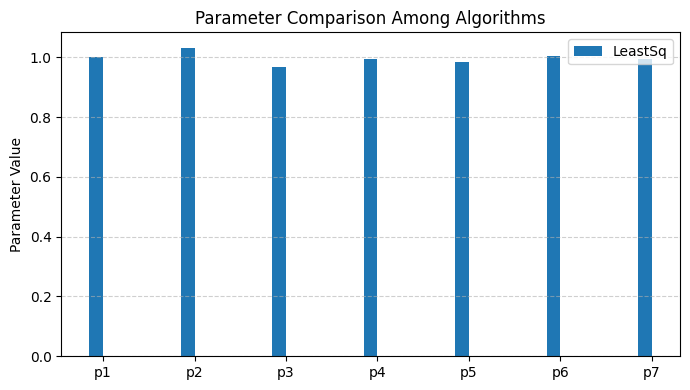

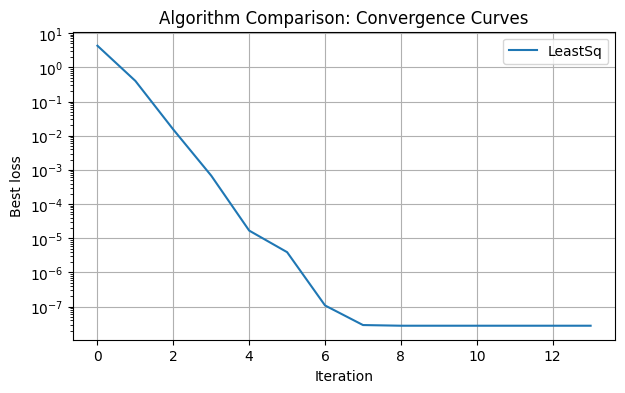


=== Final Comparison ===
LeastSq: final loss=2.7707e-08, time=1.34s, params=[1.00013502 1.03190499 0.96770254 0.99306088 0.9834158  1.00392089
 0.99428763]


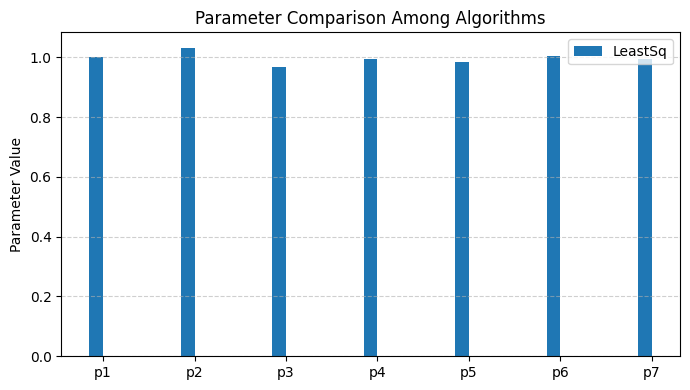

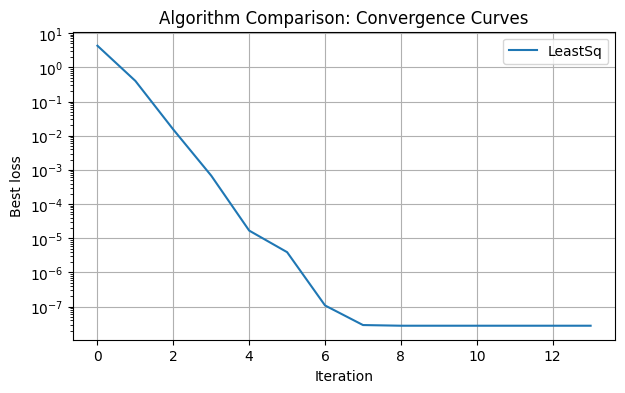


=== Final Comparison ===
LeastSq: final loss=2.7707e-08, time=1.45s, params=[1.00013502 1.03190499 0.96770254 0.99306088 0.9834158  1.00392089
 0.99428763]


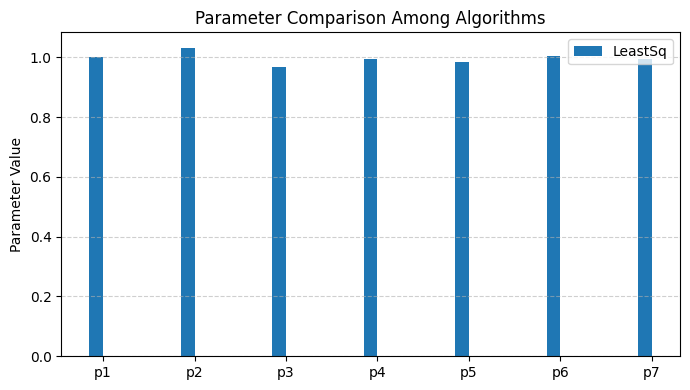

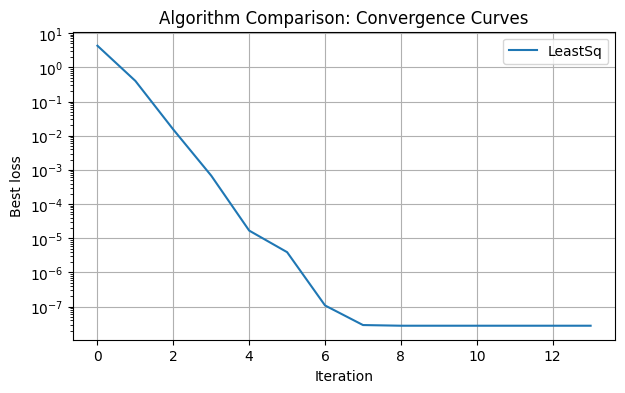


=== Final Comparison ===
LeastSq: final loss=2.7707e-08, time=1.39s, params=[1.00013502 1.03190499 0.96770254 0.99306088 0.9834158  1.00392089
 0.99428763]


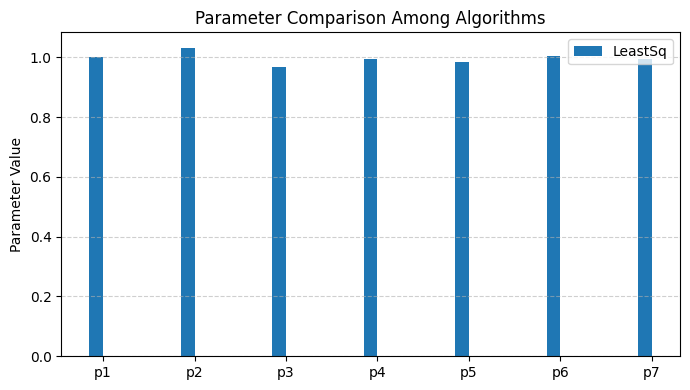

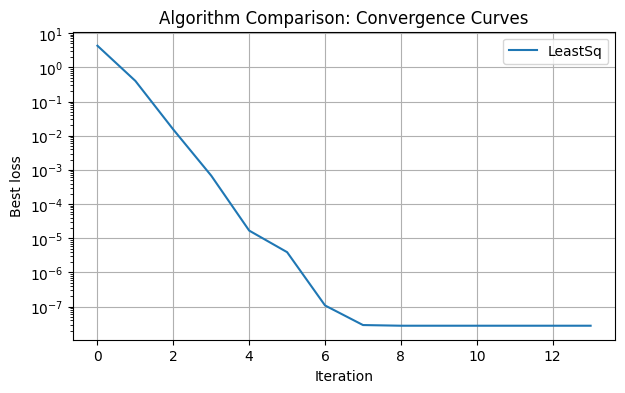


=== Final Comparison ===
LeastSq: final loss=2.7707e-08, time=1.39s, params=[1.00013502 1.03190499 0.96770254 0.99306088 0.9834158  1.00392089
 0.99428763]


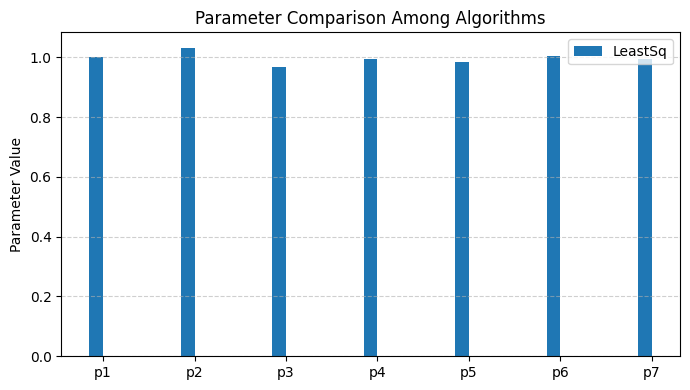

In [ ]:
# Buck converter
# 20 kHz

file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/Open_source_code/"
# Only enable the last three optimizers
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    file_path = "switchingfrequency_20kHz.csv"
    maxiteration = 500
if 1==1:
    # -----------------------------
    # Common fitness
    # -----------------------------
    def fitness(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        loss = np.mean((result_slice - target_waveform)**2) + \
            1*np.mean((result_slice_current - target_waveform_current)**2)
        return loss


    # -----------------------------
    # Simplified GA
    # -----------------------------
    def run_ga(target_waveform, target_waveform_current, dutytemp, S1,
            pop_size=30, n_gen=maxiteration):
        dim = 7
        low, high = 0.5, 3
        pop = np.random.uniform(low, high, (pop_size, dim))
        best_hist = []
        for _ in range(n_gen):
            fitness_vals = np.array([fitness(ind, target_waveform, target_waveform_current, dutytemp, S1) for ind in pop])
            best_hist.append(np.min(fitness_vals))
            parents = pop[np.argsort(fitness_vals)[:pop_size//2]]
            offspring = parents + np.random.normal(0, 0.05, parents.shape)
            offspring = np.clip(offspring, low, high)
            pop = np.vstack([parents, offspring])
        return pop[np.argmin(fitness_vals)], best_hist

    # -----------------------------
    # Simplified PSO
    # -----------------------------
    def run_pso(target_waveform, target_waveform_current, dutytemp, S1,
                n_particles=20, n_iter=maxiteration):
        dim = 7
        bounds_low, bounds_high = 0.5, 3
        pos = np.random.uniform(bounds_low, bounds_high, (n_particles, dim))
        vel = np.zeros_like(pos)
        pbest, pbest_val = pos.copy(), np.full(n_particles, np.inf)
        gbest = pos[0].copy()
        best_hist = []
        for _ in range(n_iter):
            vals = np.array([fitness(p, target_waveform, target_waveform_current, dutytemp, S1) for p in pos])
            improved = vals < pbest_val
            pbest[improved], pbest_val[improved] = pos[improved], vals[improved]
            if vals.min() < fitness(gbest, target_waveform, target_waveform_current, dutytemp, S1):
                gbest = pos[np.argmin(vals)]
            best_hist.append(vals.min())

            # Update velocity and position
            r1, r2 = np.random.rand(*pos.shape), np.random.rand(*pos.shape)
            vel = 0.7*vel + 1.5*r1*(pbest - pos) + 1.5*r2*(gbest - pos)
            pos = np.clip(pos + vel, bounds_low, bounds_high)
        return gbest, best_hist

    # -----------------------------
    # CMA-ES
    # -----------------------------
    def run_cma(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7)+0.3
        es = cma.CMAEvolutionStrategy(x0, 0.3, {'bounds':[0.5,3], 'maxiter':max_iter, 'verb_disp':0})
        best_hist = []
        while not es.stop():
            sols = es.ask()
            vals = [fitness(x, target_waveform, target_waveform_current, dutytemp, S1) for x in sols]
            es.tell(sols, vals)
            best_hist.append(np.min(vals))
        return es.result.xbest, best_hist

    # -----------------------------
    # Differential Evolution (DE)
    # -----------------------------
    def run_de(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        bounds = [(0.5,3)]*7
        result = differential_evolution(
            lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
            bounds, maxiter=max_iter, disp=False)
        best_hist = np.linspace(result.fun*2, result.fun, max_iter)
        return result.x, best_hist

    def run_lbfgs(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        # Initial estimations
        x0 = np.ones(7)+0.3
        bounds = [(0.5, 3)] * 7
        hist = []

        # Record loss in each iteration
        def callback(xk):
            val = fitness(xk, target_waveform, target_waveform_current, dutytemp, S1)
            hist.append(val)

        res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
                    x0,
                    method="L-BFGS-B",
                    bounds=bounds,
                    options={"maxiter": max_iter, 
                                "disp": True,
                                'gtol': 1e-25 ,  # Gradient tolerance
                                'ftol': 1e-25    # Function tolerance
                        },
                    callback=callback)

        if not hist:  # Avoid no callback
            hist.append(res.fun)
        return res.x, hist

    # -----------------------------
    # Least Squares
    # -----------------------------
    def residuals(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        # Voltage and current prediction errors
        res_voltage = result_slice - target_waveform
        res_current = 1 * (result_slice_current - target_waveform_current)
        return np.concatenate([res_voltage, res_current])

    def run_leastsq(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7) + 0.7
        # x0 = np.array([0.5, 0.6, 0.55, 3, 2.1, 1.1,2])
        bounds = (0.5*np.ones(7), 3*np.ones(7))
        hist = []

        def loss_fun(x):
            # Compute comparable scalar loss (MSE style)
            return fitness(x, target_waveform, target_waveform_current, dutytemp, S1)

        def callback(xk, *args, **kwargs):
            # hist.append(loss_fun(xk)**0.5)
            hist.append(loss_fun(xk))
            # hist.append(loss_fun(xk)) # The loss goes to 1e-23, which is different from the others

        res = least_squares(
            residuals,  # returns vector of residuals
            x0,
            args=(target_waveform, target_waveform_current, dutytemp, S1),
            bounds=bounds,
            max_nfev=max_iter,
            verbose=0,
            callback=callback
        )

        if not hist:  # In case callback didn’t run
            hist.append(loss_fun(res.x))
            # hist.append(loss_fun(res.fun))
        return res.x, hist

def compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1):
    results = {}
    # for name, func in [("GA", run_ga), ("PSO", run_pso), ("CMA-ES", run_cma), ("DE", run_de)]:
    for name, func in [
                    # ("GA", run_ga), 
                    # ("PSO", run_pso), 
                    # ("CMA-ES", run_cma), 
                    # ("L-BFGS-B", run_lbfgs),
                    ("LeastSq", run_leastsq) 
                    ]:
    # for name, func in [ ("L-BFGS-B", run_lbfgs)]:
        start = time.time()
        params, hist = func(target_waveform, target_waveform_current, dutytemp, S1)
        elapsed = time.time() - start
        results[name] = (params, hist, elapsed)
    #    print(name,results[name])

    # Plot loss curve
    # plt.figure(figsize=(8,5))
    plt.figure(figsize=[7,4])
    for name, (_, hist, _) in results.items():
        plt.plot(hist, label=name)
    plt.xlabel("Iteration")
    plt.ylabel("Best loss")
    plt.title("Algorithm Comparison: Convergence Curves")
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.show()
    
    print("\n=== Final Comparison ===")
    for name, (params, hist, elapsed) in results.items():
        print(f"{name:6s}: final loss={hist[-1]:.4e}, time={elapsed:.2f}s, params={params}")

    # Plot bar chart of estimations
    param_data = {name: params for name, (params, _, _) in results.items()}
    param_names = [f"p{i+1}" for i in range(len(next(iter(param_data.values()))))]

    fig, ax = plt.subplots(figsize=(7,4))
    x = np.arange(len(param_names))
    width = 0.15

    for i, (name, params) in enumerate(param_data.items()):
        ax.bar(x + i*width, params, width, label=name)

    ax.set_xticks(x + width*(len(param_data)/2))
    ax.set_xticklabels(param_names)
    ax.set_ylabel("Parameter Value")
    ax.set_title("Parameter Comparison Among Algorithms")
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return results

# With a load step
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    
    # file_path = "switchingfrequency_20kHz.csv"
    maxiteration = 500
    dt = 1e-7
    # t = np.arange(0, 0.015, dt)
    t = np.arange(0, 0.005, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5 ), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000

    df = pd.read_csv(file_path0+file_path, header=None, skiprows=1)
    df.columns = ["t","i","v", "s","vcarrier","d"]
    print(df.head())

    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    dutytemp = np.array(df['d']) 


        
    plt.figure(figsize=[7,1.5])
    plt.plot(target_waveform)
    plt.plot(target_waveform_current)
    plt.show()

# The physics model
@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 0.6e-3 * Lratio
    C  = 1440e-6 * Cratio
    Rc = 0.03 * RCratio
    Rl = 0.2 * Rlratio
    Ron = 0.05 * Rdsonratio
    Vd  = 1.0 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = 2.0 * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))
    # else:        
    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    for i in range(N):
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  
        # si = S1[i]

        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:        
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        # CCM
        if Il < 0:
            Il = 0.0

        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

#results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)

def compare_algorithms2(target_waveform, target_waveform_current, dutytemp, S1, n_repeat):
    results_all = {}
    for n_repeat_counter in range(n_repeat):
            random.seed(n_repeat_counter)    
            results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)
            results_all[n_repeat_counter] = results['LeastSq'][0] 
    return results_all

results_all = compare_algorithms2(target_waveform, target_waveform_current, dutytemp,S1,5)



      t         i          v  s  vcarrier         d
0  0.05  3.153579  47.859079  0     0.996  0.515065
1  0.05  3.136944  47.858276  0     0.992  0.515065
2  0.05  3.120309  47.857471  0     0.988  0.515065
3  0.05  3.103675  47.856665  0     0.984  0.515065
4  0.05  3.087042  47.855857  0     0.980  0.515065


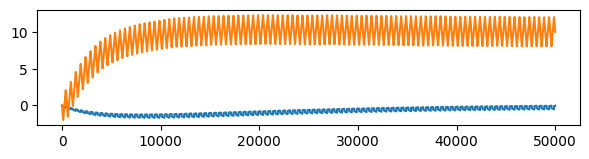


=== Final Comparison ===
LeastSq: final loss=2.5745e-04, time=2.35s, params=[0.99992541 0.99991377 1.00349814 0.99567127 1.01420279 0.9600681
 1.0277925 ]

=== Final Comparison ===
LeastSq: final loss=2.5745e-04, time=0.83s, params=[0.99992541 0.99991377 1.00349814 0.99567127 1.01420279 0.9600681
 1.0277925 ]

=== Final Comparison ===
LeastSq: final loss=2.5745e-04, time=0.97s, params=[0.99992541 0.99991377 1.00349814 0.99567127 1.01420279 0.9600681
 1.0277925 ]

=== Final Comparison ===
LeastSq: final loss=2.5745e-04, time=0.82s, params=[0.99992541 0.99991377 1.00349814 0.99567127 1.01420279 0.9600681
 1.0277925 ]

=== Final Comparison ===
LeastSq: final loss=2.5745e-04, time=0.75s, params=[0.99992541 0.99991377 1.00349814 0.99567127 1.01420279 0.9600681
 1.0277925 ]


In [ ]:
# Boost - 20 kHz 

file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/Open_source_code/"
# Only enable the last three optimizers
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    file_path = "Boostswitchingfrequency_20kHz.csv"
    maxiteration = 500
if 1==1:
    # -----------------------------
    # Common fitness
    # -----------------------------
    def fitness(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        loss = np.mean((result_slice - target_waveform)**2) + \
            1*np.mean((result_slice_current - target_waveform_current)**2)
        return loss


    # -----------------------------
    # Simplified GA
    # -----------------------------
    def run_ga(target_waveform, target_waveform_current, dutytemp, S1,
            pop_size=30, n_gen=maxiteration):
        dim = 7
        low, high = 0.5, 3
        pop = np.random.uniform(low, high, (pop_size, dim))
        best_hist = []
        for _ in range(n_gen):
            fitness_vals = np.array([fitness(ind, target_waveform, target_waveform_current, dutytemp, S1) for ind in pop])
            best_hist.append(np.min(fitness_vals))
            parents = pop[np.argsort(fitness_vals)[:pop_size//2]]
            offspring = parents + np.random.normal(0, 0.05, parents.shape)
            offspring = np.clip(offspring, low, high)
            pop = np.vstack([parents, offspring])
        return pop[np.argmin(fitness_vals)], best_hist

    # -----------------------------
    # PSO 
    # -----------------------------
    def run_pso(target_waveform, target_waveform_current, dutytemp, S1,
                n_particles=20, n_iter=maxiteration):
        dim = 7
        bounds_low, bounds_high = 0.5, 3
        pos = np.random.uniform(bounds_low, bounds_high, (n_particles, dim))
        vel = np.zeros_like(pos)
        pbest, pbest_val = pos.copy(), np.full(n_particles, np.inf)
        gbest = pos[0].copy()
        best_hist = []
        for _ in range(n_iter):
            vals = np.array([fitness(p, target_waveform, target_waveform_current, dutytemp, S1) for p in pos])
            improved = vals < pbest_val
            pbest[improved], pbest_val[improved] = pos[improved], vals[improved]
            if vals.min() < fitness(gbest, target_waveform, target_waveform_current, dutytemp, S1):
                gbest = pos[np.argmin(vals)]
            best_hist.append(vals.min())

            # Update velocity and position
            r1, r2 = np.random.rand(*pos.shape), np.random.rand(*pos.shape)
            vel = 0.7*vel + 1.5*r1*(pbest - pos) + 1.5*r2*(gbest - pos)
            pos = np.clip(pos + vel, bounds_low, bounds_high)
        return gbest, best_hist

    # -----------------------------
    # CMA-ES
    # -----------------------------
    def run_cma(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7)+0.3
        es = cma.CMAEvolutionStrategy(x0, 0.3, {'bounds':[0.5,3], 'maxiter':max_iter, 'verb_disp':0})
        best_hist = []
        while not es.stop():
            sols = es.ask()
            vals = [fitness(x, target_waveform, target_waveform_current, dutytemp, S1) for x in sols]
            es.tell(sols, vals)
            best_hist.append(np.min(vals))
        return es.result.xbest, best_hist

    # -----------------------------
    # Differential Evolution (DE)
    # -----------------------------
    def run_de(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        bounds = [(0.5,3)]*7
        result = differential_evolution(
            lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
            bounds, maxiter=max_iter, disp=False)
        best_hist = np.linspace(result.fun*2, result.fun, max_iter)
        return result.x, best_hist

    def run_lbfgs(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        # Initial estimation
        x0 = np.ones(7)+0.3
        bounds = [(0.5, 3)] * 7
        hist = []

        # Record loss in each iteration
        def callback(xk):
            val = fitness(xk, target_waveform, target_waveform_current, dutytemp, S1)
            hist.append(val)

        res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
                    x0,
                    method="L-BFGS-B",
                    bounds=bounds,
                    options={"maxiter": max_iter, 
                                "disp": True,
                                'gtol': 1e-25 ,  # Gradient tolerance
                                'ftol': 1e-25    # Function tolerance
                        },
                    callback=callback)

        if not hist:  # Avoid no callback
            hist.append(res.fun)
        return res.x, hist

    # -----------------------------
    # Least Squares
    # -----------------------------
    def residuals(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        # Voltage and current predicition errors
        res_voltage = result_slice - target_waveform
        res_current = 1 * (result_slice_current - target_waveform_current)
        return np.concatenate([res_voltage, res_current])

    def run_leastsq(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7) + 0.7
        # x0 = np.array([0.5, 0.6, 0.55, 3, 2.1, 1.1,2])
        bounds = (0.5*np.ones(7), 3*np.ones(7))
        hist = []

        def loss_fun(x):
            # Compute comparable scalar loss (MSE style)
            return fitness(x, target_waveform, target_waveform_current, dutytemp, S1)

        def callback(xk, *args, **kwargs):
            # hist.append(loss_fun(xk)**0.5)
            hist.append(loss_fun(xk))
            # hist.append(loss_fun(xk)) # The loss goes to 1e-23, which is different from the others

        res = least_squares(
            residuals,  # returns vector of residuals
            x0,
            args=(target_waveform, target_waveform_current, dutytemp, S1),
            bounds=bounds,
            max_nfev=max_iter,
            verbose=0,
            callback=callback
        )

        if not hist:  # In case callback didn’t run
            hist.append(loss_fun(res.x))
            # hist.append(loss_fun(res.fun))
        return res.x, hist

def compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1, plotTrue = 1):
    results = {}
    # for name, func in [("GA", run_ga), ("PSO", run_pso), ("CMA-ES", run_cma), ("DE", run_de)]:
    for name, func in [
                    # ("GA", run_ga), 
                    # ("PSO", run_pso), 
                    # ("CMA-ES", run_cma), 
                    # ("L-BFGS-B", run_lbfgs),
                    ("LeastSq", run_leastsq) 
                    ]:
    # for name, func in [ ("L-BFGS-B", run_lbfgs)]:
        start = time.time()
        params, hist = func(target_waveform, target_waveform_current, dutytemp, S1)
        elapsed = time.time() - start
        results[name] = (params, hist, elapsed)
    #    print(name,results[name])

    # plt.figure(figsize=(8,5))
    if plotTrue == 1:
        plt.figure(figsize=[7,4])
        for name, (_, hist, _) in results.items():
            plt.plot(hist, label=name)
        plt.xlabel("Iteration")
        plt.ylabel("Best loss")
        plt.title("Algorithm Comparison: Convergence Curves")
        plt.legend()
        plt.grid(True)
        plt.yscale('log')
        plt.show()

    print("\n=== Final Comparison ===")
    for name, (params, hist, elapsed) in results.items():
        print(f"{name:6s}: final loss={hist[-1]:.4e}, time={elapsed:.2f}s, params={params}")

    # Plot bar chart
    param_data = {name: params for name, (params, _, _) in results.items()}
    param_names = [f"p{i+1}" for i in range(len(next(iter(param_data.values()))))]

    
    if plotTrue == 1:
        fig, ax = plt.subplots(figsize=(7,4))
        x = np.arange(len(param_names))
        width = 0.15

        for i, (name, params) in enumerate(param_data.items()):
            ax.bar(x + i*width, params, width, label=name)
        ax.set_xticks(x + width*(len(param_data)/2))
        ax.set_xticklabels(param_names)
        ax.set_ylabel("Parameter Value")
        ax.set_title("Parameter Comparison Among Algorithms")
        ax.legend()
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    return results

# With a load step
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    
    # file_path = "switchingfrequency_20kHz.csv"
    maxiteration = 500
    dt = 1e-7
    # t = np.arange(0, 0.015, dt)
    t = np.arange(0, 0.005, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5+1e-7), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000

    df = pd.read_csv(file_path0+file_path, header=None, skiprows=1)
    df.columns = ["t","i","v", "s","vcarrier","d"]
    print(df.head())

    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    dutytemp = np.array(df['d']) 


        
    plt.figure(figsize=[7,1.5])
    plt.plot(target_waveform)
    plt.plot(target_waveform_current)
    plt.show()

# The physics model
@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 150e-6 * Lratio
    C  = 1000e-6 * Cratio
    Rc = 0.03 * RCratio * 1
    Rl = 0.2 * Rlratio
    Rl = 0.03 * Rlratio

    Ron = 0.05 * Rdsonratio
    Vd  = 1.0 * Vfratio

    Uin = 24.0
    Uref = 48.0
    R = 7.68 * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # # Boost
    # A11on = -(Ron + Rl)/(L)
    # A12on = 0
    # A21on = 0
    # A22on = -1/((R+Rc)*C)
    # B1on = Uin/L
    # B2on = 0
    # # else:        
    # A11off = -(Rl)/(L)
    # A12off = -1/L
    # A21off = R/(L*C) * (L-Rl*Rc*C)/(R+Rc)
    # A22off = -(L+R*Rc*C)/(L*C*(R+Rc))
    # B1off = (Uin - Vd)/L
    # B2off = Rc*R/(L*(R+Rc))*(Uin-Vd)

    # Boost
    A11on = -(Ron + Rl)/(L)
    A12on = 0
    A21on = 0
    A22on = -1/((R+Rc)*C)
    B1on = Uin/L
    B2on = 0
    # else:        
    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = R/(L*C) * (L-Rl*Rc*C)/(R+Rc)
    A22off = -(L+R*Rc*C)/(L*C*(R+Rc))
    B1off = (Uin - Vd)/L
    B2off = Rc*R/(L*(R+Rc))*(Uin-Vd)
    


    for i in range(N):
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  
        #si = S1[i]

        if i == 0:
            StepTemp0 = si # To add a jump on the vo
            jumpflag = 0
            #StepTemp1 = si # To add a jump on the vo
        else:
            if si > StepTemp0: # From off to on
                jumpflag = 1
            if si < StepTemp0:
                jumpflag = -1
            if si == StepTemp0:
                jumpflag = 0
            StepTemp0 = si # To add a jump on the vo

        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:        
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc, jumpflag):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2 + Rc*jumpflag * Il
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc, jumpflag)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc, jumpflag)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc, jumpflag) 
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc, jumpflag)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc) - Rc*jumpflag * Il

        # CCM
        if Il < 0:
            Il = 0.0

        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle



#results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)

def compare_algorithms2(target_waveform, target_waveform_current, dutytemp, S1, n_repeat, plotTrue):
    results_all = {}
    for n_repeat_counter in range(n_repeat):
            random.seed(n_repeat_counter)    
            results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1, plotTrue)
            results_all[n_repeat_counter] = results['LeastSq'][0] 
    return results_all

results_all = compare_algorithms2(target_waveform, target_waveform_current, dutytemp,S1,5,plotTrue = 0)



In [19]:
results_all[0], results_all[1],
results_all


M = np.vstack(list(results_all.values()))
median_per_param = np.median(M, axis=0)
(1-median_per_param)*100

array([ 0.00745894,  0.00862327, -0.3498144 ,  0.4328729 , -1.42027894,
        3.99318972, -2.77924972])

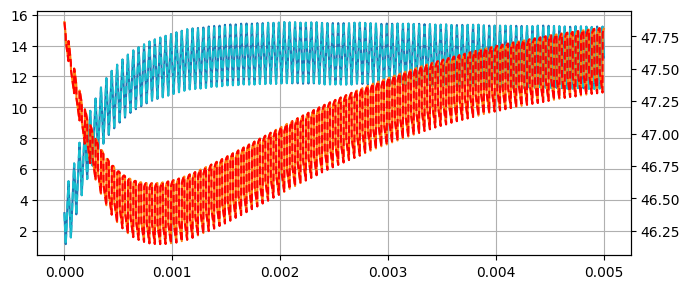

In [20]:
params = results_all[0]#results['LeastSq'][0]


# res = params
# results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)
res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t,target_waveform_current + xiv0[0], label='current',color='#1F77B4')
ax.plot(t,res[0], '--', label='current_res',color='#17BECF')
ax.grid(True)

axr = ax.twinx()

axr.plot(t,target_waveform + xiv0[1], label='voltage',color='#FF7F0E')
axr.plot(t,res[1], '--', label='voltage_res', color='#FF0000')

# ax.set_xlim([0.0009,0.001])
# ax.set_xlim([0.000985,0.00099])
# ax.set_ylim([11,13])
# axr.set_ylim([23.9,24])
plt.tight_layout()


In [23]:

file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/Open_source_code/"
# Only enable the last three optimizers
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    file_path = "Boostswitchingfrequency_20kHz.csv"
    file_path = "Boostswitchingfrequency_20kHz_long.csv"
    maxiteration = 500

# With a load step
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    
    # file_path = "switchingfrequency_20kHz.csv"
    maxiteration = 500
    dt = 1e-7
    # t = np.arange(0, 0.015, dt)
    t = np.arange(0, 0.005, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5 ), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000

    df = pd.read_csv(file_path0+file_path, header=None, skiprows=1)
    df.columns = ["t","i","v", "s","vcarrier","d"]
    print(df.head())
    t_target_waveform_long =  np.array(df['t']) - df['t'][0]
    target_waveform_long = np.array(df['v'])
    target_waveform_current_long =  np.array(df['i'])
    # S1 = np.array(df['s'])

    # xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    # x0 = np.array([target_waveform_current[0], target_waveform[0]])

    # target_waveform = target_waveform - target_waveform[0]
    # target_waveform_current = target_waveform_current - target_waveform_current[0]
    # dutytemp = np.array(df['d']) 



       t         i          v  s  vcarrier         d
0  0.045  3.210295  47.998508  0     0.996  0.513875
1  0.045  3.193566  47.998171  0     0.992  0.513875
2  0.045  3.176836  47.997832  0     0.988  0.513875
3  0.045  3.160108  47.997492  0     0.984  0.513875
4  0.045  3.143380  47.997150  0     0.980  0.513875


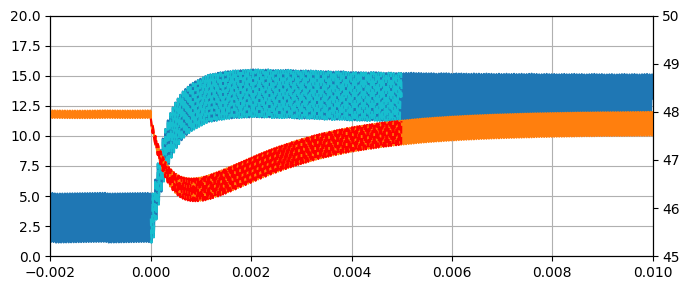

In [58]:
params = results_all[0]#results['LeastSq'][0]


# res = params
# results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)
res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)
fig, ax = plt.subplots(figsize=(7, 3))
# ax.plot(t,target_waveform_current + xiv0[0], label='current',color='#1F77B4')
ax.plot(t_target_waveform_long-0.005,target_waveform_current_long , label='current',color='#1F77B4')
ax.plot(t,res[0], '--', label='current_res',color='#17BECF')
ax.grid(True)

axr = ax.twinx()

# axr.plot(t,target_waveform + xiv0[1], label='voltage',color='#FF7F0E')
axr.plot(t_target_waveform_long-0.005,target_waveform_long , label='voltage',color='#FF7F0E')
axr.plot(t,res[1], '--', label='voltage_res', color='#FF0000')

# ax.set_xlim([0.0009,0.001])
# ax.set_xlim([0.000985,0.00099])
ax.set_ylim([0,20])
axr.set_ylim([45,50])
axr.set_xlim([-0.002,0.01])
# axr.set_ylim([23.9,24])
plt.tight_layout()


# address_fig1 =  'C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/'
# address_fig2 =  'boost_pred1'
# plt.savefig(address_fig1+address_fig2+'.svg')
# plt.savefig(address_fig1+address_fig2+'.png')
# plt.show()

# input_svg = address_fig1+address_fig2+".svg"  # Replace with your SVG file path
# output_emf = address_fig1+address_fig2+".emf" # Replace with your desired EMF file path
# export_to_emf(input_svg, output_emf)

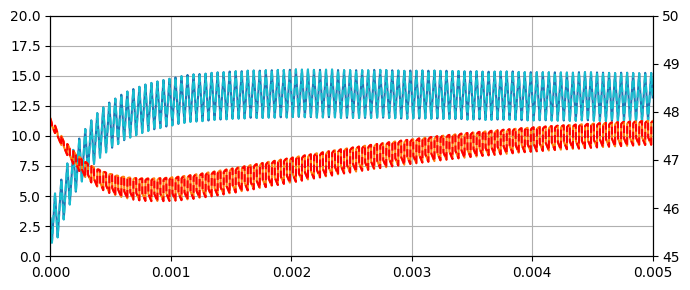

Successfully exported C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/boost_pred2.svg to C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/boost_pred2.emf.


In [51]:
params = results_all[0]#results['LeastSq'][0]


# res = params
# results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)
res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)
fig, ax = plt.subplots(figsize=(7, 3))
# ax.plot(t,target_waveform_current + xiv0[0], label='current',color='#1F77B4')
ax.plot(t_target_waveform_long-0.005,target_waveform_current_long , label='current',color='#1F77B4')
ax.plot(t,res[0], '--', label='current_res',color='#17BECF')
ax.grid(True)

axr = ax.twinx()

# axr.plot(t,target_waveform + xiv0[1], label='voltage',color='#FF7F0E')
axr.plot(t_target_waveform_long-0.005,target_waveform_long , label='voltage',color='#FF7F0E')
axr.plot(t,res[1], '--', label='voltage_res', color='#FF0000')

# ax.set_xlim([0.0009,0.001])
# ax.set_xlim([0.000985,0.00099])
ax.set_ylim([0,20])
axr.set_ylim([45,50])
axr.set_xlim([0.00,0.005])
# axr.set_ylim([23.9,24])
plt.tight_layout()


address_fig1 =  'C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/'
address_fig2 =  'boost_pred2'
plt.savefig(address_fig1+address_fig2+'.svg')
plt.savefig(address_fig1+address_fig2+'.png')
plt.show()

input_svg = address_fig1+address_fig2+".svg"  # Replace with your SVG file path
output_emf = address_fig1+address_fig2+".emf" # Replace with your desired EMF file path
export_to_emf(input_svg, output_emf)

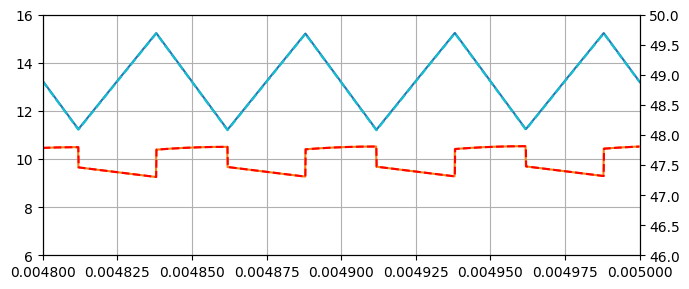

Successfully exported C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/boost_pred3.svg to C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/boost_pred3.emf.


In [54]:
params = results_all[0]#results['LeastSq'][0]


# res = params
# results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)
res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)
fig, ax = plt.subplots(figsize=(7, 3))
# ax.plot(t,target_waveform_current + xiv0[0], label='current',color='#1F77B4')
ax.plot(t_target_waveform_long-0.005,target_waveform_current_long , label='current',color='#1F77B4')
ax.plot(t,res[0], '--', label='current_res',color='#17BECF')
ax.grid(True)

axr = ax.twinx()

# axr.plot(t,target_waveform + xiv0[1], label='voltage',color='#FF7F0E')
axr.plot(t_target_waveform_long-0.005,target_waveform_long , label='voltage',color='#FF7F0E')
axr.plot(t,res[1], '--', label='voltage_res', color='#FF0000')

# ax.set_xlim([0.0009,0.001])
# ax.set_xlim([0.000985,0.00099])
ax.set_ylim([6,16])
axr.set_ylim([46,50])
axr.set_xlim([0.0048,0.005])
# axr.set_ylim([23.9,24])
plt.tight_layout()

address_fig1 =  'C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/'
address_fig2 =  'boost_pred3'
plt.savefig(address_fig1+address_fig2+'.svg')
plt.savefig(address_fig1+address_fig2+'.png')
plt.show()

input_svg = address_fig1+address_fig2+".svg"  # Replace with your SVG file path
output_emf = address_fig1+address_fig2+".emf" # Replace with your desired EMF file path
export_to_emf(input_svg, output_emf)


      t         i          v  s  vcarrier         d
0  0.05  3.227514  47.857996  0     1.000  0.512963
1  0.05  3.210878  47.857439  0     0.996  0.512963
2  0.05  3.194242  47.856881  0     0.992  0.512963
3  0.05  3.177607  47.856324  0     0.988  0.512963
4  0.05  3.160973  47.855766  0     0.984  0.512963


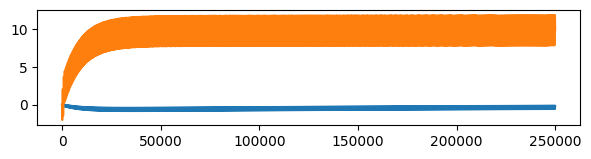

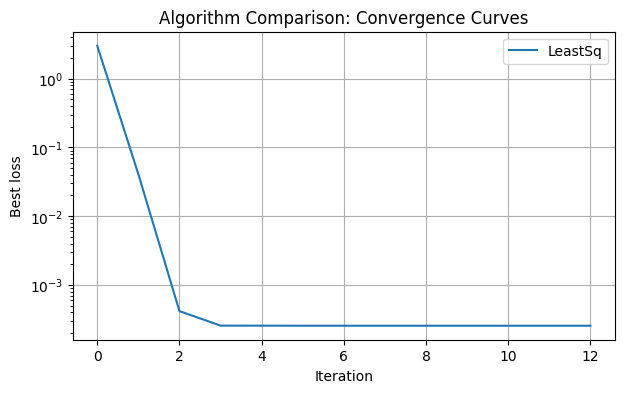


=== Final Comparison ===
LeastSq: final loss=2.5468e-04, time=6.63s, params=[1.00482419 0.99831118 1.01008381 0.99803194 0.64072989 1.31807482
 0.99906469]


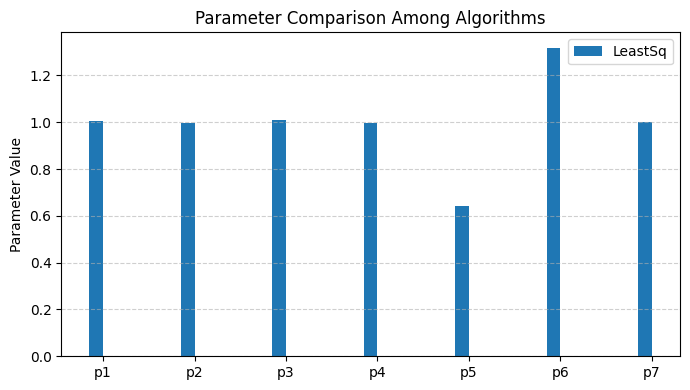

In [ ]:
# 100 kHz

file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/Open_source_code/"
# Only enable the last three optimizers
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    file_path = "Boostswitchingfrequency_100kHz.csv"
    maxiteration = 500
if 1==1:
    # -----------------------------
    # Common fitness
    # -----------------------------
    def fitness(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        loss = np.mean((result_slice - target_waveform)**2) + \
            1*np.mean((result_slice_current - target_waveform_current)**2)
        return loss


    # -----------------------------
    # Simplified GA
    # -----------------------------
    def run_ga(target_waveform, target_waveform_current, dutytemp, S1,
            pop_size=30, n_gen=maxiteration):
        dim = 7
        low, high = 0.5, 3
        pop = np.random.uniform(low, high, (pop_size, dim))
        best_hist = []
        for _ in range(n_gen):
            fitness_vals = np.array([fitness(ind, target_waveform, target_waveform_current, dutytemp, S1) for ind in pop])
            best_hist.append(np.min(fitness_vals))
            parents = pop[np.argsort(fitness_vals)[:pop_size//2]]
            offspring = parents + np.random.normal(0, 0.05, parents.shape)
            offspring = np.clip(offspring, low, high)
            pop = np.vstack([parents, offspring])
        return pop[np.argmin(fitness_vals)], best_hist

    # -----------------------------
    # PSO
    # -----------------------------
    def run_pso(target_waveform, target_waveform_current, dutytemp, S1,
                n_particles=20, n_iter=maxiteration):
        dim = 7
        bounds_low, bounds_high = 0.5, 3
        pos = np.random.uniform(bounds_low, bounds_high, (n_particles, dim))
        vel = np.zeros_like(pos)
        pbest, pbest_val = pos.copy(), np.full(n_particles, np.inf)
        gbest = pos[0].copy()
        best_hist = []
        for _ in range(n_iter):
            vals = np.array([fitness(p, target_waveform, target_waveform_current, dutytemp, S1) for p in pos])
            improved = vals < pbest_val
            pbest[improved], pbest_val[improved] = pos[improved], vals[improved]
            if vals.min() < fitness(gbest, target_waveform, target_waveform_current, dutytemp, S1):
                gbest = pos[np.argmin(vals)]
            best_hist.append(vals.min())

            # Update velocity and position
            r1, r2 = np.random.rand(*pos.shape), np.random.rand(*pos.shape)
            vel = 0.7*vel + 1.5*r1*(pbest - pos) + 1.5*r2*(gbest - pos)
            pos = np.clip(pos + vel, bounds_low, bounds_high)
        return gbest, best_hist

    # -----------------------------
    # CMA-ES
    # -----------------------------
    def run_cma(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7)+0.3
        es = cma.CMAEvolutionStrategy(x0, 0.3, {'bounds':[0.5,3], 'maxiter':max_iter, 'verb_disp':0})
        best_hist = []
        while not es.stop():
            sols = es.ask()
            vals = [fitness(x, target_waveform, target_waveform_current, dutytemp, S1) for x in sols]
            es.tell(sols, vals)
            best_hist.append(np.min(vals))
        return es.result.xbest, best_hist

    # -----------------------------
    # Differential Evolution (DE)
    # -----------------------------
    def run_de(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        bounds = [(0.5,3)]*7
        result = differential_evolution(
            lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
            bounds, maxiter=max_iter, disp=False)
        best_hist = np.linspace(result.fun*2, result.fun, max_iter)
        return result.x, best_hist

    def run_lbfgs(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        # Initial estimation
        x0 = np.ones(7)+0.3
        bounds = [(0.5, 3)] * 7
        hist = []

        # Record loss in each iteration
        def callback(xk):
            val = fitness(xk, target_waveform, target_waveform_current, dutytemp, S1)
            hist.append(val)

        res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
                    x0,
                    method="L-BFGS-B",
                    bounds=bounds,
                    options={"maxiter": max_iter, 
                                "disp": True,
                                'gtol': 1e-25 ,  # Gradient tolerance
                                'ftol': 1e-25    # Function tolerance
                        },
                    callback=callback)

        if not hist:  # Avoid no callback
            hist.append(res.fun)
        return res.x, hist

    # -----------------------------
    # Least Squares
    # -----------------------------
    def residuals(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        # Voltage and current prediction error
        res_voltage = result_slice - target_waveform
        res_current = 1 * (result_slice_current - target_waveform_current)
        return np.concatenate([res_voltage, res_current])

    def run_leastsq(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7) + 0.7
        # x0 = np.array([0.5, 0.6, 0.55, 3, 2.1, 1.1,2])
        bounds = (0.5*np.ones(7), 3*np.ones(7))
        hist = []

        def loss_fun(x):
            # Compute comparable scalar loss (MSE style)
            return fitness(x, target_waveform, target_waveform_current, dutytemp, S1)

        def callback(xk, *args, **kwargs):
            # hist.append(loss_fun(xk)**0.5)
            hist.append(loss_fun(xk))
            # hist.append(loss_fun(xk)) # The loss goes to 1e-23, which is different from the others

        res = least_squares(
            residuals,  # returns vector of residuals
            x0,
            args=(target_waveform, target_waveform_current, dutytemp, S1),
            bounds=bounds,
            max_nfev=max_iter,
            verbose=0,
            callback=callback
        )

        if not hist:  # In case callback didn’t run
            hist.append(loss_fun(res.x))
            # hist.append(loss_fun(res.fun))
        return res.x, hist

def compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1):
    results = {}
    # for name, func in [("GA", run_ga), ("PSO", run_pso), ("CMA-ES", run_cma), ("DE", run_de)]:
    for name, func in [
                    # ("GA", run_ga), 
                    # ("PSO", run_pso), 
                    # ("CMA-ES", run_cma), 
                    # ("L-BFGS-B", run_lbfgs),
                    ("LeastSq", run_leastsq) 
                    ]:
    # for name, func in [ ("L-BFGS-B", run_lbfgs)]:
        start = time.time()
        params, hist = func(target_waveform, target_waveform_current, dutytemp, S1)
        elapsed = time.time() - start
        results[name] = (params, hist, elapsed)
    #    print(name,results[name])

    # plt.figure(figsize=(8,5))
    plt.figure(figsize=[7,4])
    for name, (_, hist, _) in results.items():
        plt.plot(hist, label=name)
    plt.xlabel("Iteration")
    plt.ylabel("Best loss")
    plt.title("Algorithm Comparison: Convergence Curves")
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.show()

    print("\n=== Final Comparison ===")
    for name, (params, hist, elapsed) in results.items():
        print(f"{name:6s}: final loss={hist[-1]:.4e}, time={elapsed:.2f}s, params={params}")

    # Plot bar chart
    param_data = {name: params for name, (params, _, _) in results.items()}
    param_names = [f"p{i+1}" for i in range(len(next(iter(param_data.values()))))]

    fig, ax = plt.subplots(figsize=(7,4))
    x = np.arange(len(param_names))
    width = 0.15

    for i, (name, params) in enumerate(param_data.items()):
        ax.bar(x + i*width, params, width, label=name)

    ax.set_xticks(x + width*(len(param_data)/2))
    ax.set_xticklabels(param_names)
    ax.set_ylabel("Parameter Value")
    ax.set_title("Parameter Comparison Among Algorithms")
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return results

# With a load step
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    
    # file_path = "switchingfrequency_20kHz.csv"
    maxiteration = 500
    dt = 2e-8
    # t = np.arange(0, 0.015, dt)
    t = np.arange(0, 0.00500002, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5+1e-7), 0.5) + 1) / 2

    yt = (sawtooth(2 * np.pi * 1e5 * (t+0.5*1e-5), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000
    index2_slice = 250001

    df = pd.read_csv(file_path0+file_path, header=None, skiprows=1)
    df.columns = ["t","i","v", "s","vcarrier","d"]
    print(df.head())

    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    dutytemp = np.array(df['d']) 


        
    plt.figure(figsize=[7,1.5])
    plt.plot(target_waveform)
    plt.plot(target_waveform_current)
    plt.show()

# The physics model
@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 30e-6 * Lratio
    C  = 1000e-6 * Cratio
    Rc = 0.03 * RCratio * 1
    Rl = 0.2 * Rlratio
    Rl = 0.03 * Rlratio

    Ron = 0.05 * Rdsonratio
    Vd  = 1.0 * Vfratio

    Uin = 24.0
    Uref = 48.0
    R = 7.68 * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # # Boost
    # A11on = -(Ron + Rl)/(L)
    # A12on = 0
    # A21on = 0
    # A22on = -1/((R+Rc)*C)
    # B1on = Uin/L
    # B2on = 0
    # # else:        
    # A11off = -(Rl)/(L)
    # A12off = -1/L
    # A21off = R/(L*C) * (L-Rl*Rc*C)/(R+Rc)
    # A22off = -(L+R*Rc*C)/(L*C*(R+Rc))
    # B1off = (Uin - Vd)/L
    # B2off = Rc*R/(L*(R+Rc))*(Uin-Vd)

    # Boost
    A11on = -(Ron + Rl)/(L)
    A12on = 0
    A21on = 0
    A22on = -1/((R+Rc)*C)
    B1on = Uin/L
    B2on = 0
    # else:        
    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = R/(L*C) * (L-Rl*Rc*C)/(R+Rc)
    A22off = -(L+R*Rc*C)/(L*C*(R+Rc))
    B1off = (Uin - Vd)/L
    B2off = Rc*R/(L*(R+Rc))*(Uin-Vd)
    


    for i in range(N):
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  
        #si = S1[i]

        if i == 0:
            StepTemp0 = si # To add a jump on the vo
            jumpflag = 0
            #StepTemp1 = si # To add a jump on the vo
        else:
            if si > StepTemp0: # From off to on
                jumpflag = 1
            if si < StepTemp0:
                jumpflag = -1
            if si == StepTemp0:
                jumpflag = 0
            StepTemp0 = si # To add a jump on the vo

        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:        
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc, jumpflag):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2 + Rc*jumpflag * Il
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc, jumpflag)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc, jumpflag)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc, jumpflag) 
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc, jumpflag)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc) - Rc*jumpflag * Il

        # CCM
        if Il < 0:
            Il = 0.0

        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle




#results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)

def compare_algorithms2(target_waveform, target_waveform_current, dutytemp, S1, n_repeat):
    results_all = {}
    for n_repeat_counter in range(n_repeat):
            random.seed(n_repeat_counter)    
            results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)
            results_all[n_repeat_counter] = results['LeastSq'][0] 
    return results_all

results_all = compare_algorithms2(target_waveform, target_waveform_current, dutytemp,S1,1)



      t         i          v  s  vcarrier         d
0  0.01  3.223329  47.860087  0     1.000  0.510357
1  0.01  3.206743  47.858994  0     0.996  0.510357
2  0.01  3.190157  47.857897  0     0.992  0.510357
3  0.01  3.173572  47.856798  0     0.988  0.510357
4  0.01  3.156989  47.855695  0     0.984  0.510357


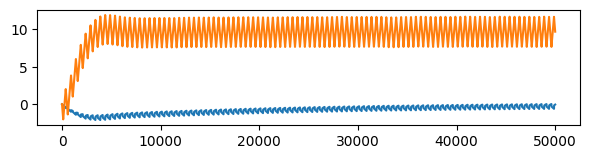

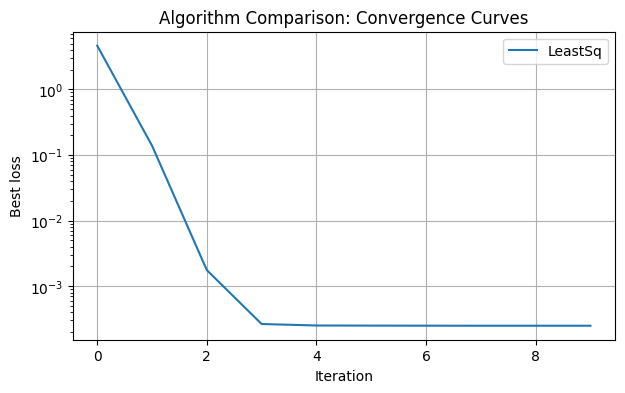


=== Final Comparison ===
LeastSq: final loss=2.4948e-04, time=1.38s, params=[1.00025024 1.0010517  1.00272149 0.99188355 1.02591757 0.5
 1.06587662]


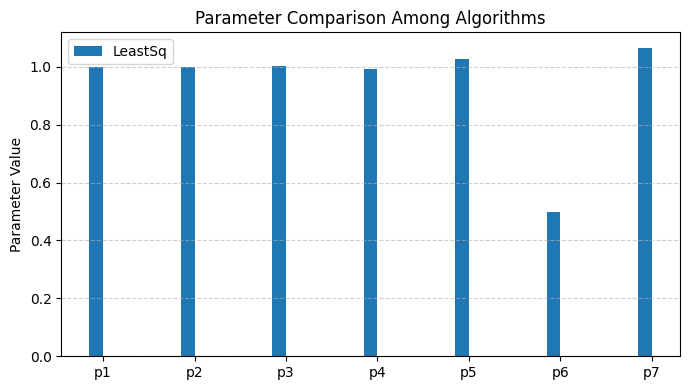

In [ ]:
# 100 kHz

file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/8_writing/J3/ResponseLetter/Open_source_code/"
# Only enable the last three optimizers
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    file_path = "Boostswitchingfrequency_100kHz.csv"
    maxiteration = 500
if 1==1:
    # -----------------------------
    # Common fitness
    # -----------------------------
    def fitness(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        loss = np.mean((result_slice - target_waveform)**2) + \
            1*np.mean((result_slice_current - target_waveform_current)**2)
        return loss


    # -----------------------------
    # Simplified GA 
    # -----------------------------
    def run_ga(target_waveform, target_waveform_current, dutytemp, S1,
            pop_size=30, n_gen=maxiteration):
        dim = 7
        low, high = 0.5, 3
        pop = np.random.uniform(low, high, (pop_size, dim))
        best_hist = []
        for _ in range(n_gen):
            fitness_vals = np.array([fitness(ind, target_waveform, target_waveform_current, dutytemp, S1) for ind in pop])
            best_hist.append(np.min(fitness_vals))
            parents = pop[np.argsort(fitness_vals)[:pop_size//2]]
            offspring = parents + np.random.normal(0, 0.05, parents.shape)
            offspring = np.clip(offspring, low, high)
            pop = np.vstack([parents, offspring])
        return pop[np.argmin(fitness_vals)], best_hist

    # -----------------------------
    # PSO
    # -----------------------------
    def run_pso(target_waveform, target_waveform_current, dutytemp, S1,
                n_particles=20, n_iter=maxiteration):
        dim = 7
        bounds_low, bounds_high = 0.5, 3
        pos = np.random.uniform(bounds_low, bounds_high, (n_particles, dim))
        vel = np.zeros_like(pos)
        pbest, pbest_val = pos.copy(), np.full(n_particles, np.inf)
        gbest = pos[0].copy()
        best_hist = []
        for _ in range(n_iter):
            vals = np.array([fitness(p, target_waveform, target_waveform_current, dutytemp, S1) for p in pos])
            improved = vals < pbest_val
            pbest[improved], pbest_val[improved] = pos[improved], vals[improved]
            if vals.min() < fitness(gbest, target_waveform, target_waveform_current, dutytemp, S1):
                gbest = pos[np.argmin(vals)]
            best_hist.append(vals.min())

            # Update velocity and position
            r1, r2 = np.random.rand(*pos.shape), np.random.rand(*pos.shape)
            vel = 0.7*vel + 1.5*r1*(pbest - pos) + 1.5*r2*(gbest - pos)
            pos = np.clip(pos + vel, bounds_low, bounds_high)
        return gbest, best_hist

    # -----------------------------
    # CMA-ES
    # -----------------------------
    def run_cma(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7)+0.3
        es = cma.CMAEvolutionStrategy(x0, 0.3, {'bounds':[0.5,3], 'maxiter':max_iter, 'verb_disp':0})
        best_hist = []
        while not es.stop():
            sols = es.ask()
            vals = [fitness(x, target_waveform, target_waveform_current, dutytemp, S1) for x in sols]
            es.tell(sols, vals)
            best_hist.append(np.min(vals))
        return es.result.xbest, best_hist

    # -----------------------------
    # Differential Evolution (DE)
    # -----------------------------
    def run_de(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        bounds = [(0.5,3)]*7
        result = differential_evolution(
            lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
            bounds, maxiter=max_iter, disp=False)
        best_hist = np.linspace(result.fun*2, result.fun, max_iter)
        return result.x, best_hist

    def run_lbfgs(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        # Initial estimation
        x0 = np.ones(7)+0.3
        bounds = [(0.5, 3)] * 7
        hist = []

        # Record loss in each iteration
        def callback(xk):
            val = fitness(xk, target_waveform, target_waveform_current, dutytemp, S1)
            hist.append(val)

        res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
                    x0,
                    method="L-BFGS-B",
                    bounds=bounds,
                    options={"maxiter": max_iter, 
                                "disp": True,
                                'gtol': 1e-25 ,  # Gradient tolerance
                                'ftol': 1e-25    # Function tolerance
                        },
                    callback=callback)

        if not hist:  # Avoid no callback
            hist.append(res.fun)
        return res.x, hist

    # -----------------------------
    # Least Squares
    # -----------------------------
    def residuals(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        # Voltage and current prediction error
        res_voltage = result_slice - target_waveform
        res_current = 1 * (result_slice_current - target_waveform_current)
        return np.concatenate([res_voltage, res_current])

    def run_leastsq(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7) + 0.7
        # x0 = np.array([0.5, 0.6, 0.55, 3, 2.1, 1.1,2])
        bounds = (0.5*np.ones(7), 3*np.ones(7))
        hist = []

        def loss_fun(x):
            # Compute comparable scalar loss (MSE style)
            return fitness(x, target_waveform, target_waveform_current, dutytemp, S1)

        def callback(xk, *args, **kwargs):
            # hist.append(loss_fun(xk)**0.5)
            hist.append(loss_fun(xk))
            # hist.append(loss_fun(xk)) # The loss goes to 1e-23, which is different from the others

        res = least_squares(
            residuals,  # returns vector of residuals
            x0,
            args=(target_waveform, target_waveform_current, dutytemp, S1),
            bounds=bounds,
            max_nfev=max_iter,
            verbose=0,
            callback=callback
        )

        if not hist:  # In case callback didn’t run
            hist.append(loss_fun(res.x))
            # hist.append(loss_fun(res.fun))
        return res.x, hist

def compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1):
    results = {}
    # for name, func in [("GA", run_ga), ("PSO", run_pso), ("CMA-ES", run_cma), ("DE", run_de)]:
    for name, func in [
                    # ("GA", run_ga), 
                    # ("PSO", run_pso), 
                    # ("CMA-ES", run_cma), 
                    # ("L-BFGS-B", run_lbfgs),
                    ("LeastSq", run_leastsq) 
                    ]:
    # for name, func in [ ("L-BFGS-B", run_lbfgs)]:
        start = time.time()
        params, hist = func(target_waveform, target_waveform_current, dutytemp, S1)
        elapsed = time.time() - start
        results[name] = (params, hist, elapsed)
    #    print(name,results[name])

    # 绘制收敛曲线
    # plt.figure(figsize=(8,5))
    plt.figure(figsize=[7,4])
    for name, (_, hist, _) in results.items():
        plt.plot(hist, label=name)
    plt.xlabel("Iteration")
    plt.ylabel("Best loss")
    plt.title("Algorithm Comparison: Convergence Curves")
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.show()

    print("\n=== Final Comparison ===")
    for name, (params, hist, elapsed) in results.items():
        print(f"{name:6s}: final loss={hist[-1]:.4e}, time={elapsed:.2f}s, params={params}")

    # Plot bar chart
    param_data = {name: params for name, (params, _, _) in results.items()}
    param_names = [f"p{i+1}" for i in range(len(next(iter(param_data.values()))))]

    fig, ax = plt.subplots(figsize=(7,4))
    x = np.arange(len(param_names))
    width = 0.15

    for i, (name, params) in enumerate(param_data.items()):
        ax.bar(x + i*width, params, width, label=name)

    ax.set_xticks(x + width*(len(param_data)/2))
    ax.set_xticklabels(param_names)
    ax.set_ylabel("Parameter Value")
    ax.set_title("Parameter Comparison Among Algorithms")
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return results

# With a load step
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    
    # file_path = "switchingfrequency_20kHz.csv"
    maxiteration = 500
    dt = 2e-8
    # t = np.arange(0, 0.015, dt)
    t = np.arange(0, 0.00100002, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5+1e-7), 0.5) + 1) / 2

    yt = (sawtooth(2 * np.pi * 1e5 * (t+0.5*1e-5), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000
    index2_slice = 50001

    df = pd.read_csv(file_path0+file_path, header=None, skiprows=1)
    df.columns = ["t","i","v", "s","vcarrier","d"]
    print(df.head())

    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    dutytemp = np.array(df['d']) 


        
    plt.figure(figsize=[7,1.5])
    plt.plot(target_waveform)
    plt.plot(target_waveform_current)
    plt.show()

# The physics model
@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 30e-6 * Lratio
    C  = 100e-6 * Cratio
    Rc = 0.03 * RCratio * 1
    # Rl = 0.2 * Rlratio
    Rl = 0.03*0.2 * Rlratio

    Ron = 0.05 * Rdsonratio
    Vd  = 1.0 * Vfratio

    Uin = 24.0
    Uref = 48.0
    R = 7.68 * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # # Boost
    # A11on = -(Ron + Rl)/(L)
    # A12on = 0
    # A21on = 0
    # A22on = -1/((R+Rc)*C)
    # B1on = Uin/L
    # B2on = 0
    # # else:        
    # A11off = -(Rl)/(L)
    # A12off = -1/L
    # A21off = R/(L*C) * (L-Rl*Rc*C)/(R+Rc)
    # A22off = -(L+R*Rc*C)/(L*C*(R+Rc))
    # B1off = (Uin - Vd)/L
    # B2off = Rc*R/(L*(R+Rc))*(Uin-Vd)

    # Boost
    A11on = -(Ron + Rl)/(L)
    A12on = 0
    A21on = 0
    A22on = -1/((R+Rc)*C)
    B1on = Uin/L
    B2on = 0
    # else:        
    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = R/(L*C) * (L-Rl*Rc*C)/(R+Rc)
    A22off = -(L+R*Rc*C)/(L*C*(R+Rc))
    B1off = (Uin - Vd)/L
    B2off = Rc*R/(L*(R+Rc))*(Uin-Vd)
    


    for i in range(N):
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  
        #si = S1[i]

        if i == 0:
            StepTemp0 = si # To add a jump on the vo
            jumpflag = 0
            #StepTemp1 = si # To add a jump on the vo
        else:
            if si > StepTemp0: # From off to on
                jumpflag = 1
            if si < StepTemp0:
                jumpflag = -1
            if si == StepTemp0:
                jumpflag = 0
            StepTemp0 = si # To add a jump on the vo

        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:        
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc, jumpflag):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2 + Rc*jumpflag * Il
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc, jumpflag)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc, jumpflag)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc, jumpflag) 
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc, jumpflag)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc) - Rc*jumpflag * Il

        # CCM
        if Il < 0:
            Il = 0.0

        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle


#results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)

def compare_algorithms2(target_waveform, target_waveform_current, dutytemp, S1, n_repeat):
    results_all = {}
    for n_repeat_counter in range(n_repeat):
            random.seed(n_repeat_counter)    
            results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)
            results_all[n_repeat_counter] = results['LeastSq'][0] 
    return results_all

results_all = compare_algorithms2(target_waveform, target_waveform_current, dutytemp,S1,1)



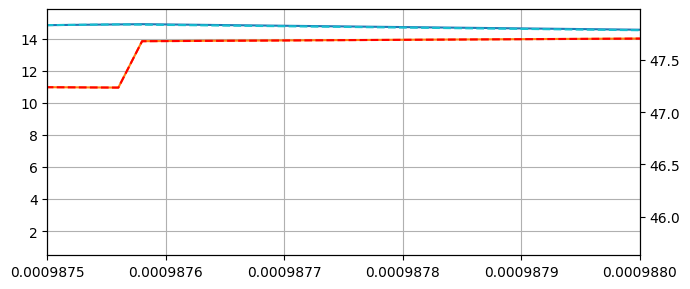

In [126]:
params = results_all[0]#results['LeastSq'][0]


# res = params
# results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)
res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t,target_waveform_current + xiv0[0], label='current',color='#1F77B4')
ax.plot(t,res[0], '--', label='current_res',color='#17BECF')
ax.grid(True)

axr = ax.twinx()

axr.plot(t,target_waveform + xiv0[1], label='voltage',color='#FF7F0E')
axr.plot(t,res[1], '--', label='voltage_res', color='#FF0000')

# ax.set_xlim([0.0009,0.001])
ax.set_xlim([0.0009875,0.000988])
# ax.set_ylim([11,13])
# axr.set_ylim([23.9,24])
plt.tight_layout()
